<a href="https://colab.research.google.com/github/vyakhyaagoyal/aiml_colab_sem-4/blob/main/VyakhyaG_AIML_B1_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

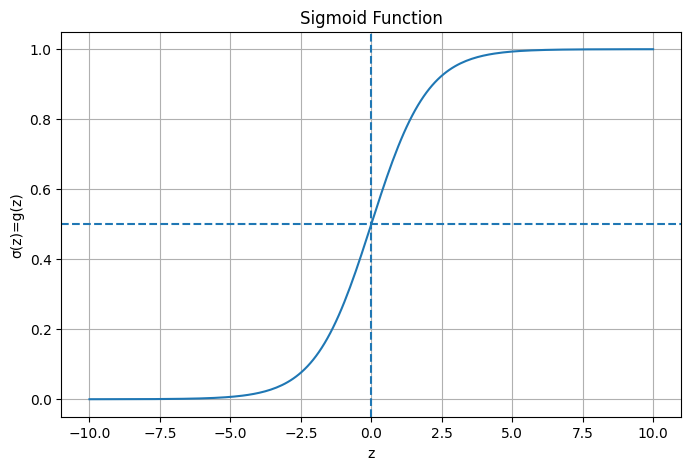

In [ ]:
#Understand the role of the sigmoid function
import numpy as np
import matplotlib.pyplot as plt

# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Create values from -10 to 10
z = np.linspace(-10, 10, 200)

# Apply sigmoid function
y = sigmoid(z)

# Plot the curve
plt.figure(figsize=(8,5))
plt.plot(z, y)

# Draw horizontal and vertical reference lines
plt.axhline(0.5, linestyle='--')
plt.axvline(0, linestyle='--')

# Add labels
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)=g(z)")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


In [ ]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
print("Dataset shape:", dataset.shape)
print("\nDataset info:")
dataset.info()
print("\nNull values:")
print(dataset.isnull().sum())

Dataset shape: (400, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

Null values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [ ]:
print(dataset['Purchased'].value_counts())

Purchased
0    257
1    143
Name: count, dtype: int64


In [ ]:
print(dataset['Purchased'].value_counts(normalize=True) * 100)

Purchased
0    64.25
1    35.75
Name: proportion, dtype: float64


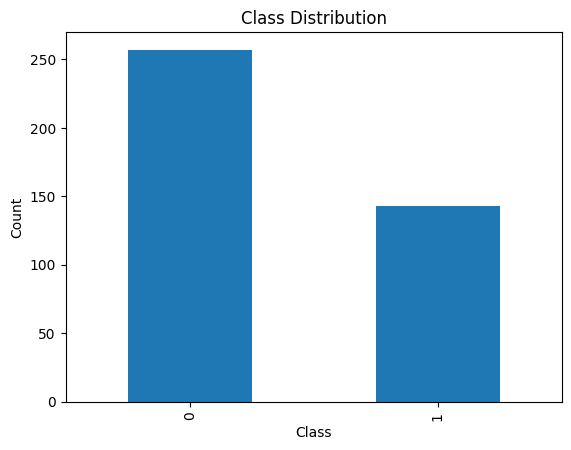

In [ ]:
import matplotlib.pyplot as plt

dataset['Purchased'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
X = dataset[['Age', 'EstimatedSalary']]
y = dataset['Purchased']

print("Features (X):")
display(X.head())

print("Target (y):")
display(y.head())

Features (X):


,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


Target (y):


,Purchased
0,0
1,0
2,0
3,0
4,0


In [ ]:
from sklearn.model_selection import train_test_split

X = dataset[['Age', 'EstimatedSalary']]
y = dataset['Purchased']

Roll_No=12
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=Roll_No)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (280, 2)
X_test shape : (120, 2)
y_train shape: (280,)
y_test shape : (120,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
sc = StandardScaler()
# Learn mean and standard deviation from training data, then scale training data
X_train = sc.fit_transform(X_train)
# Scale test data using the same mean and standard deviation learned from training data
X_test = sc.transform(X_test)
print("First 5 scaled training samples:")
print(X_train[:5])

First 5 scaled training samples:
[[-0.51506712  2.43892175]
 [-1.09079084 -1.02710704]
 [-0.03529735 -0.51473757]
 [-0.89888293  0.44972262]
 [ 0.15661056  1.112789  ]]


In [ ]:
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)
print("Model trained successfully.")
print("Intercept (theta0):", classifier.intercept_)
print("Coefficients (theta1):", classifier.coef_)

Model trained successfully.
Intercept (theta0): [-1.22156483]
Coefficients (theta1): [[2.63379343 1.13781763]]


In [ ]:
classifier.score(X_train,y_train)

0.875

In [ ]:
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)
display("Predicted classes (first 10):")
print(y_pred[:10])
print("\nPredicted probabilities (first 10):")
print(y_prob[:10])


'Predicted classes (first 10):'

[1 0 1 0 0 1 0 0 1 0]

Predicted probabilities (first 10):
[[0.00743387 0.99256613]
 [0.67769372 0.32230628]
 [0.01500055 0.98499945]
 [0.97077397 0.02922603]
 [0.96313681 0.03686319]
 [0.084043   0.915957  ]
 [0.99422022 0.00577978]
 [0.94577716 0.05422284]
 [0.00784624 0.99215376]
 [0.85039388 0.14960612]]


In [ ]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

result.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
5,1,1
6,0,0
7,0,0
8,1,1
9,0,0


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[61 12]
 [ 9 38]]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.825
Precision: 0.76
Recall   : 0.8085106382978723
F1-score : 0.7835051546391752


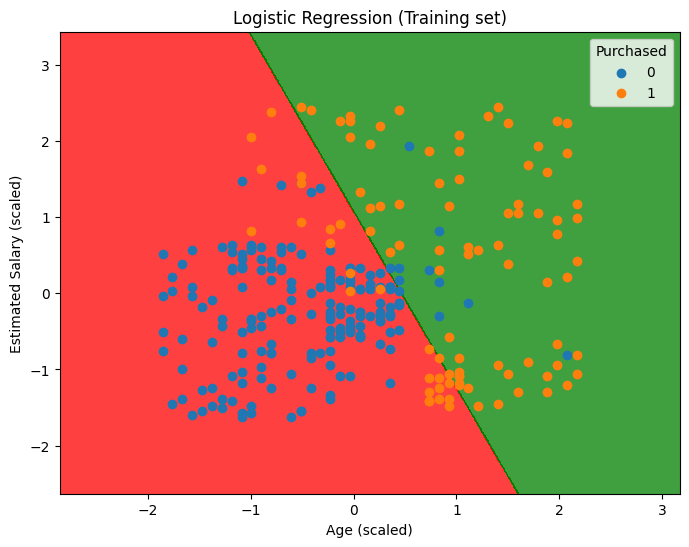

In [ ]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure(figsize=(8, 6))
plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.legend(title="Purchased")
plt.show()

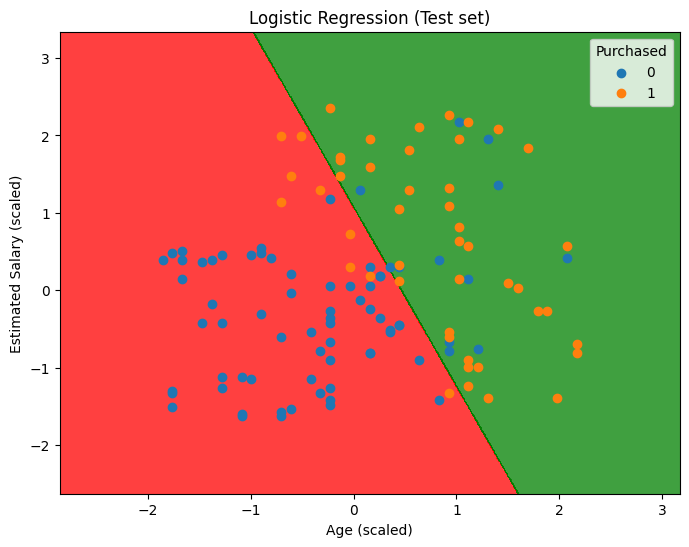

In [ ]:
X_set, y_set = X_test, y_test.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure(figsize=(8, 6))
plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        label=j
    )

plt.title('Logistic Regression (Test set)')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.legend(title="Purchased")
plt.show()

In [ ]:
prob_table = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted_Class": y_pred[:10],
    "P(Not Purchased=0)": y_prob[:10, 0],
    "P(Purchased=1)": y_prob[:10, 1]
})
prob_table

,Actual,Predicted_Class,P(Not Purchased=0),P(Purchased=1)
0,1,1,0.007434,0.992566
1,0,0,0.677694,0.322306
2,1,1,0.015001,0.984999
3,0,0,0.970774,0.029226
4,0,0,0.963137,0.036863
5,1,1,0.084043,0.915957
6,0,0,0.994220,0.005780
7,0,0,0.945777,0.054223
8,1,1,0.007846,0.992154
9,0,0,0.850394,0.149606


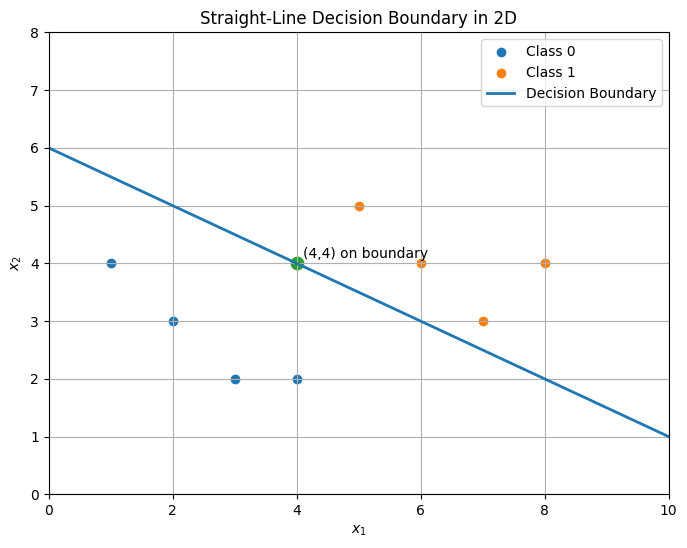

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
theta0 = -12
theta1 = 1
theta2 = 2

# Sample points
class0 = np.array([
    [2, 3],
    [3, 2],
    [4, 2],
    [1, 4]
])

class1 = np.array([
    [6, 4],
    [7, 3],
    [8, 4],
    [5, 5]
])

# Decision boundary line
# theta0 + theta1*x1 + theta2*x2 = 0
# x2 = -(theta0 + theta1*x1) / theta2
x1_vals = np.linspace(0, 10, 200)
x2_vals = -(theta0 + theta1 * x1_vals) / theta2

# Plot
plt.figure(figsize=(8, 6))

# Plot class points
plt.scatter(class0[:, 0], class0[:, 1], label='Class 0')
plt.scatter(class1[:, 0], class1[:, 1], label='Class 1')

# Plot boundary
plt.plot(x1_vals, x2_vals, linewidth=2, label='Decision Boundary')

# Mark one boundary point
plt.scatter(4, 4, s=80)
plt.text(4.1, 4.1, '(4,4) on boundary')

# Labels
plt.title('Straight-Line Decision Boundary in 2D')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.xlim(0, 10)
plt.ylim(0, 8)
plt.legend()
plt.grid(True)
plt.show()